In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/')

['GN3415.JPG',
 'CLASSXCERTIFICATE.pdf',
 'CLASSXIICERTIFICATE.pdf',
 'IMG_20251008_221259_817.jpg',
 'Colab Notebooks',
 'Screenshot_2025-10-18-19-34-34-410.jpeg',
 'Screenshot_2025-10-18-19-15-43-761.jpeg',
 'Screenshot_2025-10-18-19-09-09-216.jpeg',
 'Classroom',
 'Screenshot_20251102_173920_Chrome.jpg',
 'Screenshot_20251102_174135_Chrome.jpg',
 'Untitled spreadsheet (1).gsheet',
 'ISLR_copy.pdf',
 'Invictus 2K26.pdf',
 'https:  www.cou.txt',
 'Coursera',
 'idea.docx',
 'resume (1).docx',
 "I am sharing 'resume' with you (1).pdf",
 'resume.pdf',
 'resume.docx',
 "I am sharing 'SOP' with you.pdf",
 'SOP.pdf',
 'Untitled spreadsheet.gsheet',
 "I am sharing 'resume' with you.pdf",
 'archive.zip']

In [ ]:
os.system('unzip /content/drive/MyDrive/archive.zip -d /content/dataset')

0

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.system('unzip /content/drive/MyDrive/archive.zip -d /content/dataset')

Mounted at /content/drive


0

Simple Framework for Contrastive Learning of Visual Representations

In [ ]:



#Simple Framework for Contrastive Learning of Visual Representations (simCLR)


import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

# Dataset
class UnlabeledDataset(Dataset):
  def __init__(self, img_dir, transform=None):
    self.img_dir = img_dir
    self.images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    self.transform = transform

  def __getitem__(self, idx):
    img = Image.open(os.path.join(self.img_dir, self.images[idx])).convert('RGB')
    if self.transform:
      return self.transform(img)
    return img

  def __len__(self):
    return len(self.images)

# Augmentation
class SimCLRTransform:
  def __init__(self, size=224):
    self.transform = T.Compose([
        T.RandomResizedCrop(size),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.4, 0.4, 0.4, 0.1),
        T.RandomGrayscale(p=0.2),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
         [0.229, 0.224, 0.225])
        ])

  def __call__(self, x):
    return self.transform(x), self.transform(x)

# Model
class SimCLR(nn.Module):
  def __init__(self, projection_dim=128):
    super().__init__()
    resnet = models.resnet18(weights=None)
    self.encoder = nn.Sequential(*list(resnet.children())[:-1])
    self.projector = nn.Sequential(
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, projection_dim)
        )

  def forward(self, x):
    h = self.encoder(x).squeeze()
    z = self.projector(h)
    return h, z

# Loss
def nt_xent_loss(z1, z2, temperature=0.5):
  N = z1.shape[0]
  z = torch.cat([z1, z2], dim=0)
  z = F.normalize(z, dim=1)
  sim = torch.mm(z, z.T) / temperature
  mask = torch.eye(2*N, dtype=bool).to(z.device)
  sim.masked_fill_(mask, float('-inf'))
  labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)
  loss = F.cross_entropy(sim, labels)
  return loss

# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = SimCLR().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/ssl_project/simclr_epoch28.pt'))

optimizer = torch.optim.SGD(model.parameters(), lr=0.06, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

dataset = UnlabeledDataset('/content/dataset/ROD-Dataset/dataset/train/images',transform=SimCLRTransform())
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)

for epoch in range(28,40):
  total_loss=0
  for (x1, x2) in loader:
    x1, x2 = x1.to(device), x2.to(device)
    _, z1 = model(x1)
    _, z2 = model(x2)
    loss = nt_xent_loss(z1, z2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  scheduler.step()
  avg_loss = total_loss/len(loader)
  print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')
  torch.save
  if (epoch + 1) % 2 == 0:
    torch.save(model.state_dict(), f'/content/drive/MyDrive/ssl_project/simclr_epoch{epoch+1}.pt')
    print(f'Checkpoint saved epoch {epoch+1}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Epoch 29, Loss: 3.9281
Epoch 30, Loss: 3.9269
Checkpoint saved epoch 30
Epoch 31, Loss: 3.9192
Epoch 32, Loss: 3.9161
Checkpoint saved epoch 32
Epoch 33, Loss: 3.9086
Epoch 34, Loss: 3.9086
Checkpoint saved epoch 34
Epoch 35, Loss: 3.9010
Epoch 36, Loss: 3.8952
Checkpoint saved epoch 36
Epoch 37, Loss: 3.8901
Epoch 38, Loss: 3.8856
Checkpoint saved epoch 38
Epoch 39, Loss: 3.8789
Epoch 40, Loss: 3.8771
Checkpoint saved epoch 40


MASKED AUTOENCODER

In [ ]:


# MASKED AUTOENCODER (MAE)


from google.colab import drive
drive.mount('/content/drive')

import os
os.system('unzip /content/drive/MyDrive/archive.zip -d /content/dataset')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# Dataset
class UnlabeledDataset(Dataset):
    def __init__(self, img_dir, transform=None):
      self.img_dir = img_dir
      self.images = [f for f in os.listdir(img_dir)
      if f.endswith(('.jpg', '.png', '.jpeg'))]
      self.transform = transform

    def __getitem__(self, idx):
      img = Image.open(os.path.join(self.img_dir, self.images[idx])).convert('RGB')
      if self.transform:
        return self.transform(img)
      return img
    def __len__(self):
      return len(self.images)
mae_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
     [0.229, 0.224, 0.225]
                )])

# Patch embedding
class PatchEmbed(nn.Module):
  def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=256):
    super().__init__()
    self.num_patches = (img_size // patch_size) ** 2
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
  def forward(self, x):
    x = self.proj(x)
    x = x.flatten(2).transpose(1, 2)
    return x

# MAE Model
class MAE(nn.Module):
  def __init__(self, img_size=224, patch_size=16, embed_dim=256,encoder_depth=4, decoder_depth=2, num_heads=8, mask_ratio=0.75):
    super().__init__()
    self.patch_embed = PatchEmbed(img_size, patch_size, embed_dim=embed_dim)
    num_patches = self.patch_embed.num_patches
    self.mask_ratio = mask_ratio
    self.patch_size = patch_size

# Encoder
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
    encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=512, batch_first=True)
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=encoder_depth)

# Decoder
    self.decoder_embed = nn.Linear(embed_dim, 256)
    self.mask_token = nn.Parameter(torch.zeros(1, 1, 256))
    self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, 256))
    decoder_layer = nn.TransformerDecoderLayer(d_model=256, nhead=4, dim_feedforward=256, batch_first=True)
    self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_depth)
    self.decoder_pred = nn.Linear(256, patch_size**2 * 3)

  def patchify(self, imgs):
    p = self.patch_size
    h = w = imgs.shape[2] // p
    x = imgs.reshape(imgs.shape[0], 3, h, p, w, p)
    x = torch.einsum('nchpwq->nhwpqc', x)
    x = x.reshape(imgs.shape[0], h * w, p**2 * 3)
    return x

  def forward(self, x):
    # Patch embed
    patches = self.patch_embed(x)
    B, N, D = patches.shape

    # Add positional embededding
    patches = patches + self.pos_embed[:, 1:, :]

    # Masking
    num_mask = int(N * self.mask_ratio)
    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, num_mask:]
    visible = torch.gather(patches, 1, ids_keep.unsqueeze(-1).repeat(1, 1, D))

    # Encode visible patche
    cls_tokens = self.cls_token.expand(B, -1, -1)
    visible = torch.cat([cls_tokens, visible], dim=1)
    encoded = self.encoder(visible)

    # Decode encoded = self.decoder_embed(encoded[:, 1:, :])
    encoded_no_cls = self.decoder_embed(encoded[:, 1:, :])
    mask_tokens = self.mask_token.repeat(B, num_mask, 1)
    decoded = torch.cat([encoded_no_cls, mask_tokens], dim=1)
    decoded = decoded + self.decoder_pos_embed[:, :decoded.shape[1], :]
    memory = torch.zeros(B, 1, 256).to(x.device)
    decoded = self.decoder(decoded, memory)
    pred = self.decoder_pred(decoded)

    # Loss on masked patches only
    target = self.patchify(x)
    mask_ids = ids_shuffle[:, :num_mask]
    target_masked = torch.gather(target, 1, mask_ids.unsqueeze(-1).repeat(1, 1, target.shape[-1]))
    pred_masked = pred[:, ids_keep.shape[1]:, :]
    loss = F.mse_loss(pred_masked, target_masked)
    return loss, encoded

# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model = MAE().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.06, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
dataset = UnlabeledDataset('/content/dataset/ROD-Dataset/dataset/train/images', transform=mae_transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)
for epoch in range(40):
  total_loss = 0
  for x in loader:
                      x = x.to(device)
                      loss, _ = model(x)
                      optimizer.zero_grad()
                      loss.backward()
                      optimizer.step()
                      total_loss += loss.item()
  scheduler.step()
  avg_loss = total_loss/len(loader)
  print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')
  torch.save(model.state_dict(), f'/content/drive/MyDrive/ssl_project/mae_epoch{epoch+1}.pt')
  print(f'Checkpoint saved epoch {epoch+1}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Epoch 1, Loss: 1.1330
Checkpoint saved epoch 1
Epoch 2, Loss: 1.0595
Checkpoint saved epoch 2
Epoch 3, Loss: 1.0512
Checkpoint saved epoch 3
Epoch 4, Loss: 1.0484
Checkpoint saved epoch 4
Epoch 5, Loss: 1.0455
Checkpoint saved epoch 5
Epoch 6, Loss: 1.0427
Checkpoint saved epoch 6
Epoch 7, Loss: 1.0411
Checkpoint saved epoch 7
Epoch 8, Loss: 1.0408
Checkpoint saved epoch 8
Epoch 9, Loss: 1.0410
Checkpoint saved epoch 9
Epoch 10, Loss: 1.0391
Checkpoint saved epoch 10
Epoch 11, Loss: 1.0390
Checkpoint saved epoch 11
Epoch 12, Loss: 1.0387
Checkpoint saved epoch 12
Epoch 13, Loss: 1.0387
Checkpoint saved epoch 13
Epoch 14, Loss: 1.0388
Checkpoint saved epoch 14
Epoch 15, Loss: 1.0372
Checkpoint saved epoch 15
Epoch 16, Loss: 1.0379
Checkpoint saved epoch 16
Epoch 17, Loss: 1.0375
Checkpoint saved epoch 17
Epoch 18, Loss: 1.0374
Checkpoint sav

EVALUATION

In [ ]:


#EVALUATION


!pip install umap-learn -q
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score
import umap
import json

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
class LabeledDataset(Dataset):
  def __init__(self, img_dir, label_dir, transform=None):
    self.img_dir = img_dir
    self.label_dir = label_dir
    self.transform = transform
    self.images = [f for f in os.listdir(img_dir)
    if f.endswith(('.jpg', '.png', '.jpeg'))]

  def __getitem__(self, idx):
    img_name = self.images[idx]
    img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = os.path.join(self.label_dir, label_name)
    label = -1
    if os.path.exists(label_path):
      with open(label_path) as f:
        line = f.readline().strip()
        if line:
          label = int(line.split()[0])
    if self.transform:
      img = self.transform(img)
      return img, label
  def __len__(self):
    return len(self.images)

In [ ]:
class PatchEmbed(nn.Module):
  def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=256):
    super().__init__()
    self.num_patches = (img_size // patch_size) ** 2
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
  def forward(self, x):
    x = self.proj(x)
    x = x.flatten(2).transpose(1, 2)
    return x

In [ ]:
class MAE(nn.Module):
  def __init__(self, img_size=224, patch_size=16, embed_dim=256, encoder_depth=4, decoder_depth=2, num_heads=8, mask_ratio=0.75):
    super().__init__()
    self.patch_embed = PatchEmbed(img_size, patch_size, embed_dim=embed_dim)
    num_patches = self.patch_embed.num_patches
    self.mask_ratio = mask_ratio
    self.patch_size = patch_size
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
    encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=512, batch_first=True)
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=encoder_depth)
    self.decoder_embed = nn.Linear(embed_dim, 256)
    self.mask_token = nn.Parameter(torch.zeros(1, 1, 256))
    self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, 256))
    decoder_layer = nn.TransformerDecoderLayer(d_model=256, nhead=4, dim_feedforward=256, batch_first=True)
    self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_depth)
    self.decoder_pred = nn.Linear(256, patch_size**2 * 3)

In [ ]:
def forward_encoder(self, x):
  patches = self.patch_embed(x)
  B, N, D = patches.shape
  patches = patches + self.pos_embed[:, 1:, :]
  num_mask = int(N * self.mask_ratio)
  noise = torch.rand(B, N, device=x.device)
  ids_shuffle = torch.argsort(noise, dim=1)
  ids_keep = ids_shuffle[:, num_mask:]
  visible = torch.gather(patches, 1, ids_keep.unsqueeze(-1).repeat(1, 1, D))
  cls_tokens = self.cls_token.expand(B, -1, -1)
  visible = torch.cat([cls_tokens, visible], dim=1)
  encoded = self.encoder(visible)
  return encoded[:, 0, :]

MAE.forward_encoder = forward_encoder

In [ ]:
class SimCLR(nn.Module):
  def __init__(self, projection_dim=128):
    super().__init__()
    resnet = models.resnet18(weights=None)
    self.encoder = nn.Sequential(*list(resnet.children())[:-1])
    self.projector = nn.Sequential(nn.Linear(512, 512),nn.ReLU(),nn.Linear(512, projection_dim))

  def forward(self, x):
    h = self.encoder(x).squeeze()
    z = self.projector(h)
    return h, z

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
eval_transform = T.Compose([T.Resize((224, 224)),T.ToTensor(),T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

simclr = SimCLR().to(device)
simclr.load_state_dict(torch.load('/content/drive/MyDrive/ssl_project/simclr_epoch40.pt', map_location=device))
simclr.eval()

mae = MAE().to(device)
mae.load_state_dict(torch.load('/content/drive/MyDrive/ssl_project/mae_epoch40.pt', map_location=device))
mae.eval()
print('Both models loaded.')


Both models loaded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/ssl_project'))

['simclr_epoch2.pt', 'simclr_epoch4.pt', 'simclr_epoch6.pt', 'simclr_epoch8.pt', 'simclr_epoch10.pt', 'simclr_epoch12.pt', 'simclr_epoch14.pt', 'simclr_epoch16.pt', 'simclr_epoch18.pt', 'simclr_epoch20.pt', 'simclr_epoch22.pt', 'simclr_epoch24.pt', 'simclr_epoch26.pt', 'simclr_epoch28.pt', 'simclr_epoch30.pt', 'simclr_epoch32.pt', 'simclr_epoch34.pt', 'simclr_epoch36.pt', 'simclr_epoch38.pt', 'simclr_epoch40.pt', 'mae_epoch1.pt', 'mae_epoch2.pt', 'mae_epoch3.pt', 'mae_epoch4.pt', 'mae_epoch5.pt', 'mae_epoch6.pt', 'mae_epoch7.pt', 'mae_epoch8.pt', 'mae_epoch9.pt', 'mae_epoch10.pt', 'mae_epoch11.pt', 'mae_epoch12.pt', 'mae_epoch13.pt', 'mae_epoch14.pt', 'mae_epoch15.pt', 'mae_epoch16.pt', 'mae_epoch17.pt', 'mae_epoch18.pt', 'mae_epoch19.pt', 'mae_epoch20.pt', 'mae_epoch21.pt', 'mae_epoch22.pt', 'mae_epoch23.pt', 'mae_epoch24.pt', 'mae_epoch25.pt', 'mae_epoch26.pt', 'mae_epoch27.pt', 'mae_epoch28.pt', 'mae_epoch29.pt', 'mae_epoch30.pt', 'mae_epoch31.pt', 'mae_epoch32.pt', 'mae_epoch33.pt'

In [ ]:
test_dataset = LabeledDataset('/content/dataset/ROD-Dataset/dataset/test/images',
                              '/content/dataset/ROD-Dataset/dataset/test/labels',
                              transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
import numpy as np
simclr_emb, mae_emb, all_labels = [], [], []

with torch.no_grad():
  for imgs, labels in test_loader:
    imgs = imgs.to(device)
    h, _ = simclr(imgs)
    simclr_emb.append(h.cpu().numpy())
    m = mae.forward_encoder(imgs)
    mae_emb.append(m.cpu().numpy())
    all_labels.extend(labels.numpy())

simclr_emb = np.concatenate(simclr_emb)
mae_emb = np.concatenate(mae_emb)
all_labels = np.array(all_labels)

valid = all_labels >= 0
simclr_emb = simclr_emb[valid]
mae_emb = mae_emb[valid]
all_labels = all_labels[valid]
print(f'Embeddings extracted: {len(all_labels)} images')

KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


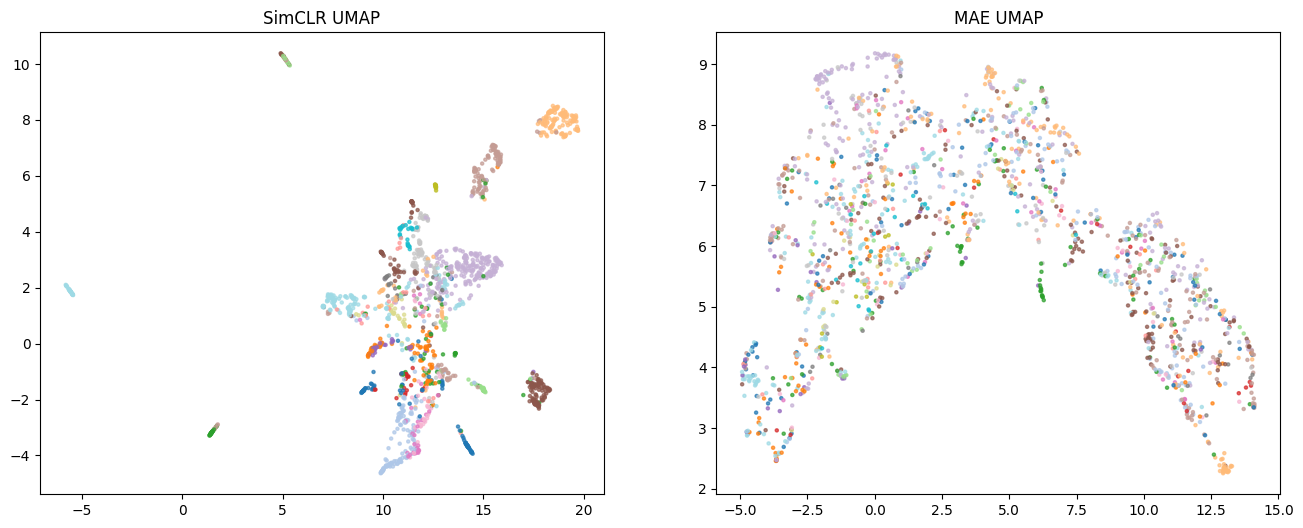

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
simclr_umap = reducer.fit_transform(simclr_emb)
mae_umap = reducer.fit_transform(mae_emb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(simclr_umap[:,0], simclr_umap[:,1], c=all_labels, cmap='tab20', s=5, alpha=0.7)
axes[0].set_title('SimCLR UMAP')
axes[1].scatter(mae_umap[:,0], mae_umap[:,1], c=all_labels, cmap='tab20', s=5, alpha=0.7)
axes[1].set_title('MAE UMAP')
plt.savefig('/content/drive/MyDrive/ssl_project/umap.png', dpi=150)
plt.show()

In [ ]:
train_dataset = LabeledDataset(
    '/content/dataset/ROD-Dataset/dataset/train/images',
    '/content/dataset/ROD-Dataset/dataset/train/labels',
    transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=0)

s_train, m_train, t_labels = [], [], []
with torch.no_grad():
  for imgs, labels in train_loader:
    imgs = imgs.to(device)
    h, _ = simclr(imgs)
    s_train.append(h.cpu().numpy())
    m = mae.forward_encoder(imgs)
    m_train.append(m.cpu().numpy())
    t_labels.extend(labels.numpy())

s_train = np.concatenate(s_train)
m_train = np.concatenate(m_train)
t_labels = np.array(t_labels)
valid_t = t_labels >= 0
s_train = s_train[valid_t]
m_train = m_train[valid_t]
t_labels = t_labels[valid_t]

clf_s = LogisticRegression(max_iter=1000, random_state=42)
clf_s.fit(s_train, t_labels)
acc_s = accuracy_score(all_labels, clf_s.predict(simclr_emb))

clf_m = LogisticRegression(max_iter=1000, random_state=42)
clf_m.fit(m_train, t_labels)
acc_m = accuracy_score(all_labels, clf_m.predict(mae_emb))
print(f'SimCLR Linear Probe: {acc_s*100:.2f}%')
print(f'MAE Linear Probe: {acc_m*100:.2f}%')


KeyboardInterrupt: 

In [ ]:
acc_s=0.8196
acc_m=0.4119
sil_s = silhouette_score(simclr_emb, all_labels, sample_size=500)
sil_m = silhouette_score(mae_emb, all_labels, sample_size=500)
print(f'SimCLR Silhouette: {sil_s:.4f}')
print(f'MAE Silhouette: {sil_m:.4f}')

aug_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

img_list = [f for f in os.listdir('/content/dataset/ROD-Dataset/dataset/test/images')
if f.endswith(('.jpg','.png','.jpeg'))][:200]
s_sims, m_sims = [], []

with torch.no_grad():
  for img_name in img_list:
    img = Image.open(os.path.join('/content/dataset/ROD-Dataset/dataset/test/images', img_name)).convert('RGB')
    v1 = eval_transform(img).unsqueeze(0).to(device)
    v2 = aug_transform(img).unsqueeze(0).to(device)
    h1, _ = simclr(v1)
    h2, _ = simclr(v2)
    s_sims.append(F.cosine_similarity(h1, h2,dim=-1).item())
    m1 = mae.forward_encoder(v1)
    m2 = mae.forward_encoder(v2)
    m_sims.append(F.cosine_similarity(m1, m2, dim=-1).item())

print(f'SimCLR Semantic Consistency: {np.mean(s_sims):.4f}')
print(f'MAE Semantic Consistency: {np.mean(m_sims):.4f}')

SimCLR Silhouette: 0.0490
MAE Silhouette: -0.3254
SimCLR Semantic Consistency: 0.8900
MAE Semantic Consistency: 0.6212


TypeError: Object of type float32 is not JSON serializable